1. Instalación

In [1]:
# Instalar dependencias (ejecutar solo la primera vez)
%pip install biopython localcider matplotlib torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


2. Imports

In [2]:
import os
import csv
import shutil

from itertools import combinations

from Bio import AlignIO
from localcider.sequenceParameters import SequenceParameters
from pathlib import Path

import matplotlib.pyplot as plt


Confirmación del directorio y creación de carpetas

In [3]:


NOTEBOOK_DIR = Path.cwd()

print("Directorio actual:", NOTEBOOK_DIR)

os.makedirs("../results", exist_ok=True)
os.makedirs("../results/csv", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)



Directorio actual: C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\notebooks


3. Cargar MSA

In [4]:
E1A_FILE = "../data/E1A_MSA.fasta"

alineamiento = AlignIO.read(
    open(E1A_FILE),
    "fasta"
)

print("Cantidad de secuencias:", len(alineamiento))

Cantidad de secuencias: 116


4.Funciones

Identidad()


In [5]:
# ==================================================
# FUNCIONES DE ANÁLISIS DE SECUENCIAS
# ==================================================


def identidad(seq1, seq2):
    """
    Calcula el porcentaje de identidad entre dos secuencias
    ignorando las posiciones con gaps.
    """

    matcheo = 0
    mismacheo = 0

    longitud = len(seq1)

    for pos in range(longitud):

        if seq1[pos] != "-" and seq2[pos] != "-":

            if seq1[pos] == seq2[pos]:
                matcheo += 1
            else:
                mismacheo += 1

    return matcheo / (matcheo + mismacheo)

contar_aminoacidos()

In [6]:
def contar_aminoacidos(seq):
    """
    Cuenta la frecuencia de cada aminoácido presente
    en una secuencia.
    """

    conteo = {}

    for aa in seq:

        if aa in conteo:
            conteo[aa] += 1
        else:
            conteo[aa] = 1

    return conteo

contar_aminoacidos_totales()

In [7]:
def contar_aminoacidos_totales(alineamiento):

    conteo = {}

    for i in range(len(alineamiento)):

        for aa in alineamiento[i].seq:

            if aa in conteo:
                conteo[aa] += 1
            else:
                conteo[aa] = 1

    return conteo

calcular_cargas()

In [8]:
def calcular_cargas(secuencia):
    """
    Calcula la cantidad de aminoácidos con carga positiva,
    negativa y neutra presentes en la secuencia.
    """
    cargas = {
        '+': 0,
        '-': 0,
        'neutro': 0
    }

    aminoacidos_cargados = {
        'R': '+',
        'K': '+',
        'D': '-',
        'E': '-',
        'H': '+',
        'C': 'neutro',
        'Y': 'neutro'
    }

    for aminoacido in secuencia:

        if aminoacido in aminoacidos_cargados:

            carga = aminoacidos_cargados[aminoacido]

            cargas[carga] += 1

    return cargas

carga_neta()

In [9]:
def carga_neta(secuencia):
    """
    Calcula la carga neta de una secuencia utilizando
    los aminoácidos cargados R, K, D y E.
    """
    carga = 0

    aminoacidos_cargados = {
        'R': 1,
        'K': 1,
        'D': -1,
        'E': -1
    }

    for aminoacido in secuencia:

        if aminoacido in aminoacidos_cargados:

            carga += aminoacidos_cargados[aminoacido]

    return carga

radio()

In [10]:
def radio(secuencia):
    """
    Estima el radio hidrodinámico de una proteína a partir
    de su longitud, contenido de prolina y carga neta.
    """
    prol = contar_aminoacidos(secuencia).get("P", 0)

    carga = carga_neta(secuencia)

    longitud = len(
        secuencia.replace("-", "")
    )

    if longitud == 0:
        return 0

    rh = (
        (1.24 * prol / longitud + 0.904)
        * (0.00759 * abs(carga) + 0.963)
        * 2.49
        * 0.901
        * longitud ** 0.509
    )

    return rh

kappa()

In [11]:
def kappa(secuencia):
    """
    Calcula el parámetro kappa utilizando LocalCIDER,
    que describe la distribución de cargas en la secuencia.
    """
    seq = SequenceParameters(
        str(secuencia).replace("-", "")
    )

    return seq.get_kappa()

resultadosPrimarios()

In [12]:
def resultadosPrimarios(alineamiento):
    """
    Genera un archivo CSV con longitud, radio hidrodinámico
    y valor de kappa para cada proteína del alineamiento.
    """
    documento = open(
        "../results/csv/primary_results.csv",
        "w"
    )

    documento.write(
    "Proteina;Longitud;Radio_Hidrodinamico;Kappa\n"
    )

    for seq in alineamiento:

        nombre = seq.id.split("|")[3]

        l = str(
            len(seq.seq.replace("-", ""))
        )

        r = str(radio(seq.seq))

        k = str(kappa(seq.seq))

        texto = (
            nombre + ";"
            + l + ";"
            + r + ";"
            + k + "\n"
        )

        documento.write(texto)

    documento.close()

5. Longitud promedio

In [13]:
# ==================================================
# CÁLCULO DE ESTADÍSTICAS BÁSICAS
# ==================================================


suma = 0

for registro in alineamiento:

    longitud = len(
        registro.seq.replace("-", "")
    )

    print(
        registro.id.split("|")[3],
        longitud
    )

    suma += longitud

print(
    "Longitud promedio:",
    suma / len(alineamiento)
)

EA.EAdV1 188
TSA.TSAdV1 179
HC.HAdV1 289
HC.HAdV2 289
HC.HAdV5 289
HC.HAdV6 289
HC.HAdV57 289
HC.SAdV31 281
HC.SAdV34 280
HC.SAdV40 280
HC.SAdV42 279
HC.SAdV43 274
HC.SAdV44 279
HC.SAdV45 274
HG.SAdV1 232
HG.HAdV52 233
HF.HAdV40 249
HF.HAdV41 251
HE.HAdV4 257
HE.SAdV22 258
HE.SAdV23 258
HE.SAdV24 258
HE.SAdV25 257
HE.SAdV26 257
HE.SAdV30 258
HE.SAdV36 258
HE.SAdV37 258
HE.SAdV38 258
HE.SAdV39 258
HE.ChAdVY25 257
HD.HAdV8 253
HD.HAdV9 251
HD.HAdV10 251
HD.HAdV13 253
HD.HAdV15 253
HD.HAdV17 253
HD.HAdV19 253
HD.HAdV20 253
HD.HAdV22 253
HD.HAdV23 253
HD.HAdV24 253
HD.HAdV25 253
HD.HAdV26 251
HD.HAdV27 251
HA.HAdV12 266
HA.HAdV18 278
HA.HAdV61 264
HA.HAdV31 265
HB.HAdV3 261
HB.HAdV7 261
HB.HAdV11 262
HB.HAdV14 261
HB.HAdV16 261
HB.HAdV21 261
HB.HAdV34 262
HB.HAdV35 262
HB.HAdV50 261
HB.HAdV55 262
HB.SAdV21 262
HB.SAdV27 261
HB.SAdV28 260
HB.SAdV29 261
HB.SAdV32 261
HB.SAdV33 261
HB.SAdV35 262
HB.SAdV41 261
HB.SAdV46 261
HB.SAdV47 261
HD.HAdV28 253
HD.HAdV29 251
HD.HAdV30 253
HD.HAdV32 251


6. Divergencia / identidad

In [14]:
for reg in combinations(alineamiento, 2):

    print(
        reg[0].id.split("|")[3],
        reg[1].id.split("|")[3],
        identidad(
            reg[0].seq,
            reg[1].seq
        )
    )

EA.EAdV1 TSA.TSAdV1 0.17518248175182483
EA.EAdV1 HC.HAdV1 0.18125
EA.EAdV1 HC.HAdV2 0.1875
EA.EAdV1 HC.HAdV5 0.1875
EA.EAdV1 HC.HAdV6 0.1875
EA.EAdV1 HC.HAdV57 0.1875
EA.EAdV1 HC.SAdV31 0.1875
EA.EAdV1 HC.SAdV34 0.20625
EA.EAdV1 HC.SAdV40 0.20625
EA.EAdV1 HC.SAdV42 0.2125
EA.EAdV1 HC.SAdV43 0.1870967741935484
EA.EAdV1 HC.SAdV44 0.20625
EA.EAdV1 HC.SAdV45 0.1870967741935484
EA.EAdV1 HG.SAdV1 0.2152777777777778
EA.EAdV1 HG.HAdV52 0.2152777777777778
EA.EAdV1 HF.HAdV40 0.1891891891891892
EA.EAdV1 HF.HAdV41 0.174496644295302
EA.EAdV1 HE.HAdV4 0.20625
EA.EAdV1 HE.SAdV22 0.21875
EA.EAdV1 HE.SAdV23 0.23125
EA.EAdV1 HE.SAdV24 0.225
EA.EAdV1 HE.SAdV25 0.225
EA.EAdV1 HE.SAdV26 0.225
EA.EAdV1 HE.SAdV30 0.225
EA.EAdV1 HE.SAdV36 0.21875
EA.EAdV1 HE.SAdV37 0.225
EA.EAdV1 HE.SAdV38 0.225
EA.EAdV1 HE.SAdV39 0.225
EA.EAdV1 HE.ChAdVY25 0.22012578616352202
EA.EAdV1 HD.HAdV8 0.19375
EA.EAdV1 HD.HAdV9 0.1962025316455696
EA.EAdV1 HD.HAdV10 0.1962025316455696
EA.EAdV1 HD.HAdV13 0.19375
EA.EAdV1 HD.HAdV15 0.19

7. Conteo de aminoácidos

In [15]:
conteo_total = contar_aminoacidos_totales(
    alineamiento
)

print(conteo_total)

{'M': 686, '-': 17997, 'K': 701, 'L': 3000, 'R': 1373, 'T': 1240, 'P': 3173, 'C': 963, 'S': 2347, 'E': 3374, 'A': 1696, 'F': 849, 'V': 1808, 'G': 1556, 'D': 2658, 'W': 58, 'Q': 788, 'Y': 639, 'N': 798, 'H': 798, 'I': 942}


Guardar

In [16]:
with open(
    "../results/csv/average_amino_acid_composition.csv",
    "w"
) as documento:

    documento.write(
        str(conteo_total)
    )

8. Radio y Kappa

In [17]:
resultadosPrimarios(alineamiento)

9. Gráficos

In [18]:
# ==================================================
# GENERACIÓN DE GRÁFICOS
# ==================================================

radioGrafico = []
kappaGrafico = []
longitudGrafico = []

for secuencia in alineamiento:

    radioGrafico.append(
        radio(secuencia.seq)
    )

    kappaGrafico.append(
        kappa(secuencia.seq)
    )

    longitudGrafico.append(
        len(secuencia.seq.replace("-", ""))
    )

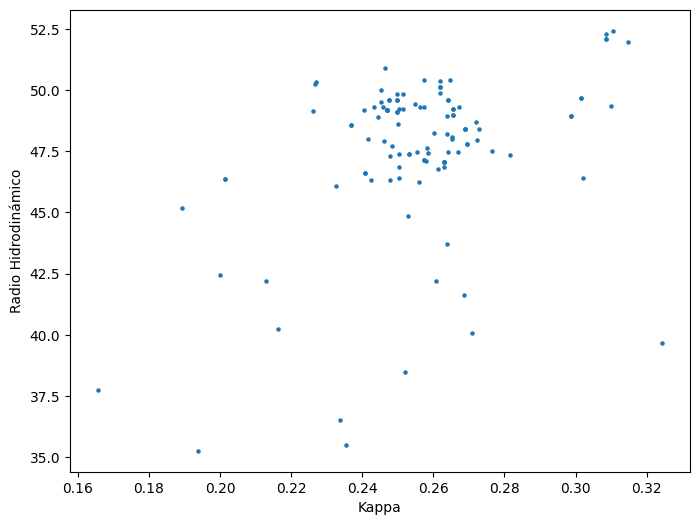

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    kappaGrafico,
    radioGrafico,
    s=5
)

plt.xlabel("Kappa")
plt.ylabel("Radio Hidrodinámico")

plt.savefig(
    "../results/figures/kappa_vs_radius.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Longitud vs Radio

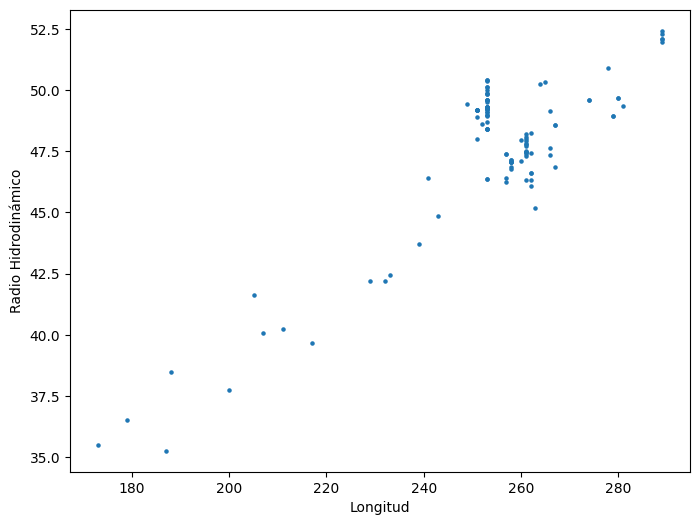

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    longitudGrafico,
    radioGrafico,
    s=5
)

plt.xlabel("Longitud")
plt.ylabel("Radio Hidrodinámico")

plt.savefig(
    "../results/figures/length_vs_radius.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

10 - AIUPred

Archivos de entrada

In [26]:
# ==================================================
# ANÁLISIS DE DESORDEN CON AIUPRED
# ==================================================


E1A_MSA1 = "../data/E1A_MSA1.fasta"
E1A_MSA2 = "../data/E1A_MSA2.fasta"

E1A_MSA_sin_gaps1 = "../data/E1A_MSA_sin_gaps1.fasta"
E1A_MSA_sin_gaps2 = "../data/E1A_MSA_sin_gaps2.fasta"

AIUPRED_PATH = Path("../tools/AIUPred/AIUPred-1.0/aiupred.py")

Ejecutar AIUPred

In [31]:
os.makedirs("../results", exist_ok=True)

"""
Ejecuta AIUPred sobre los archivos FASTA preparados
y guarda las predicciones de desorden en archivos TXT.
"""

# Ejecutar AIUPred
!python {AIUPRED_PATH} -i $E1A_MSA_sin_gaps1 -o ../results/resultadosE1A_sin_gaps1.txt

!python {AIUPRED_PATH} -i $E1A_MSA_sin_gaps2 -o ../results/resultadosE1A_sin_gaps2.txt

!python {AIUPRED_PATH} -i $E1A_MSA1 -o ../results/resultadosE1A_con_gaps1.txt

!python {AIUPRED_PATH} -i $E1A_MSA2 -o ../results/resultadosE1A_con_gaps2.txt

#             _____ _    _ _____              _ 
#       /\   |_   _| |  | |  __ \            | |
#      /  \    | | | |  | | |__) | __ ___  __| |
#     / /\ \   | | | |  | |  ___/ '__/ _ \/ _` |
#    / ____ \ _| |_| |__| | |   | | |  __/ (_| |
#   /_/    \_\_____|\____/|_|   |_|  \___|\__,_|
#
# Gabor Erdos, Zsuzsanna Dosztanyi
# v0.9, Submitted to NAR Webserver issue 2024

# Warning: No GPU found, running on CPU. It is advised to run AIUPred on a GPU


C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred.py:31: SyntaxWarning: invalid escape sequence '\ '
  #       /\   |_   _| |  | |  __ \            | |
C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred_lib.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, 2)


#             _____ _    _ _____              _ 
#       /\   |_   _| |  | |  __ \            | |
#      /  \    | | | |  | | |__) | __ ___  __| |
#     / /\ \   | | | |  | |  ___/ '__/ _ \/ _` |
#    / ____ \ _| |_| |__| | |   | | |  __/ (_| |
#   /_/    \_\_____|\____/|_|   |_|  \___|\__,_|
#
# Gabor Erdos, Zsuzsanna Dosztanyi
# v0.9, Submitted to NAR Webserver issue 2024

# Warning: No GPU found, running on CPU. It is advised to run AIUPred on a GPU


C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred.py:31: SyntaxWarning: invalid escape sequence '\ '
  #       /\   |_   _| |  | |  __ \            | |
C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred_lib.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, 2)


#             _____ _    _ _____              _ 
#       /\   |_   _| |  | |  __ \            | |
#      /  \    | | | |  | | |__) | __ ___  __| |
#     / /\ \   | | | |  | |  ___/ '__/ _ \/ _` |
#    / ____ \ _| |_| |__| | |   | | |  __/ (_| |
#   /_/    \_\_____|\____/|_|   |_|  \___|\__,_|
#
# Gabor Erdos, Zsuzsanna Dosztanyi
# v0.9, Submitted to NAR Webserver issue 2024

# Warning: No GPU found, running on CPU. It is advised to run AIUPred on a GPU


C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred.py:31: SyntaxWarning: invalid escape sequence '\ '
  #       /\   |_   _| |  | |  __ \            | |
C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred_lib.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, 2)


#             _____ _    _ _____              _ 
#       /\   |_   _| |  | |  __ \            | |
#      /  \    | | | |  | | |__) | __ ___  __| |
#     / /\ \   | | | |  | |  ___/ '__/ _ \/ _` |
#    / ____ \ _| |_| |__| | |   | | |  __/ (_| |
#   /_/    \_\_____|\____/|_|   |_|  \___|\__,_|
#
# Gabor Erdos, Zsuzsanna Dosztanyi
# v0.9, Submitted to NAR Webserver issue 2024

# Warning: No GPU found, running on CPU. It is advised to run AIUPred on a GPU


C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred.py:31: SyntaxWarning: invalid escape sequence '\ '
  #       /\   |_   _| |  | |  __ \            | |
C:\Users\fran_\Desktop\Programacion 2\bioinformatics-e1a-analysis\tools\AIUPred\AIUPred-1.0\aiupred_lib.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, 2)


Combinar resultados

In [32]:
"""
Une los resultados parciales generados por AIUPred
en archivos únicos para su posterior análisis.
"""

with open("../results/resultadosE1A_sin_gaps.txt", "wb") as salida:

    for archivo in [
        "../results/resultadosE1A_sin_gaps1.txt",
        "../results/resultadosE1A_sin_gaps2.txt"
    ]:

        with open(archivo, "rb") as entrada:
            shutil.copyfileobj(entrada, salida)

with open("../results/resultadosE1A_con_gaps.txt", "wb") as salida:

    for archivo in [
        "../results/resultadosE1A_con_gaps1.txt",
        "../results/resultadosE1A_con_gaps2.txt"
    ]:

        with open(archivo, "rb") as entrada:
            shutil.copyfileobj(entrada, salida)

Convertir salida AIUPred a CSV

In [29]:
"""
Convierte la salida de AIUPred a un formato tabular
que puede integrarse con el alineamiento original.
"""


E1A_AIUPRED = "../results/resultadosE1A_sin_gaps.txt"

ALINEAMIENTO_DESORDEN = "../results/csv/disorder_alignment.csv"

with open(ALINEAMIENTO_DESORDEN, "w") as grabar:

    with open(E1A_AIUPRED, "r") as archivo:

        for linea in archivo:

            if linea:

                if linea[0] != "\n" and linea[0] != "#":

                    if linea[0] == ">":

                        grabar.write(
                            "\n" +
                            linea.split("|")[3]
                        )

                    else:

                        grabar.write(
                            ";" +
                            linea.split()[2]
                        )

Reconstruir gaps

In [30]:
ALINEAMIENTO_DESORDEN_GAPS = \
    "../results/csv/disorder_alignment_with_gaps.csv"

with open(
    ALINEAMIENTO_DESORDEN,
    "r",
    newline=""
) as archivo:

    lector = csv.reader(
        archivo,
        delimiter=";"
    )

    next(lector)

    lineas = list(lector)

with open(
    ALINEAMIENTO_DESORDEN_GAPS,
    "w"
) as grabar:

    j = 0

    for secu in alineamiento:

        grabar.write(
            "\n" +
            secu.id.split("|")[3]
        )

        caminador = 1

        for pos in secu.seq:

            if pos != "-":

                grabar.write(
                    ";" +
                    lineas[j][caminador]
                )

                caminador += 1

            else:

                grabar.write(";")

        j += 1